# Esercizio 02 — Integrazione Monte Carlo e Random Walk

In questa esercitazione si studiano due applicazioni dei metodi Monte Carlo: la stima numerica di un integrale unidimensionale e la simulazione di random walk tridimensionali. In entrambi i casi il punto centrale non è solo ottenere una stima del valore medio, ma associare alla stima una incertezza statistica tramite **data blocking**.

I dati mostrati nei grafici sono prodotti dai codici C++ e salvati in file di testo nella cartella `results/`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.size": 12,
    "figure.figsize": (9, 5),
    "axes.grid": True,
})

# Lettura sicura da file
def load_three_columns(filename):
    path = Path(filename)
    if not path.exists():
        raise FileNotFoundError(
            f"File non trovato: {path}. "
            "Esegui prima il codice C++ e controlla che la cartella results/ sia accanto al notebook."
        )
    return np.loadtxt(path)

## Esercizio 02.1 — Integrazione Monte Carlo

Si vuole stimare l'integrale

$$
I = \int_0^1 \frac{\pi}{2}\cos\left(\frac{\pi x}{2}\right)\,dx = 1.
$$

La consegna richiede due stime indipendenti: una con campionamento uniforme in $[0,1]$ e una con importance sampling. In entrambi i casi le stime progressive e le incertezze sono ottenute tramite data blocking.


### Metodo

Nel campionamento uniforme l'integrale viene interpretato come media dell'integranda

$$
f(x)=\frac{\pi}{2}\cos\left(\frac{\pi x}{2}\right),
$$

con $x$ estratto uniformemente in $[0,1]$:

$$
I \simeq \frac{1}{M}\sum_{i=1}^{M} f(x_i).
$$

Nell'importance sampling si introduce invece una densità di probabilità $p(x)$ e si riscrive

$$
I = \int_0^1 \frac{f(x)}{p(x)}p(x)\,dx.
$$

Quindi, se $x_i$ è campionato secondo $p(x)$, la quantità da mediare è $f(x_i)/p(x_i)$:

$$
I \simeq \frac{1}{M}\sum_{i=1}^{M}\frac{f(x_i)}{p(x_i)}, \qquad x_i\sim p(x).
$$

Se la densità di probabilità $p(x)$ ha una forma simile all'integranda, il rapporto $f(x)/p(x)$ risulta più piatto rispetto a $f(x)$. Nel caso ideale, in cui $p(x)$ è proporzionale all'integranda, il rapporto diventa una costante e la varianza della stima si annulla. In pratica l'importance sampling non cambia la legge asintotica di convergenza del metodo Monte Carlo, ma riduce la varianza e quindi permette di ottenere, a parità di lanci, un'incertezza statistica più piccola.

Nel codice è stata scelta

$$
p(x)=2(1-x), \qquad x\in[0,1],
$$

perché è normalizzata e segue qualitativamente l'andamento decrescente dell'integranda. In particolare, vicino a $x=1$ l'integranda si annulla linearmente, quindi una densità proporzionale a $1-x$ è una scelta naturale e semplice. La cumulativa è

$$
F(x)=\int_0^x 2(1-t)\,dt = 2x-x^2.
$$

Invertendo $y=F(x)$ si ottiene

$$
x=1-\sqrt{1-y}, \qquad y\sim U(0,1).
$$

Nel C++ questa scelta compare direttamente nella generazione della variabile campionata, con `x = 1.0 - sqrt(1.0 - y)`. Subito dopo, nella media Monte Carlo, non si somma più solo l'integranda $f(x)$, ma il peso $f(x)/p(x)$. Questo è il passaggio essenziale dell'importance sampling.

In [2]:
# File prodotti dal codice C++ dell'esercizio 02.1
uniform_data = load_three_columns("results/montecarlo_unif_results.txt")
importance_data = load_three_columns("results/montecarlo_impsamp_taylor_results.txt")

blocks_uniform = uniform_data[:, 0]
integral_uniform = uniform_data[:, 1]
error_uniform = uniform_data[:, 2]

blocks_importance = importance_data[:, 0]
integral_importance = importance_data[:, 1]
error_importance = importance_data[:, 2]

exact_integral = 1.0

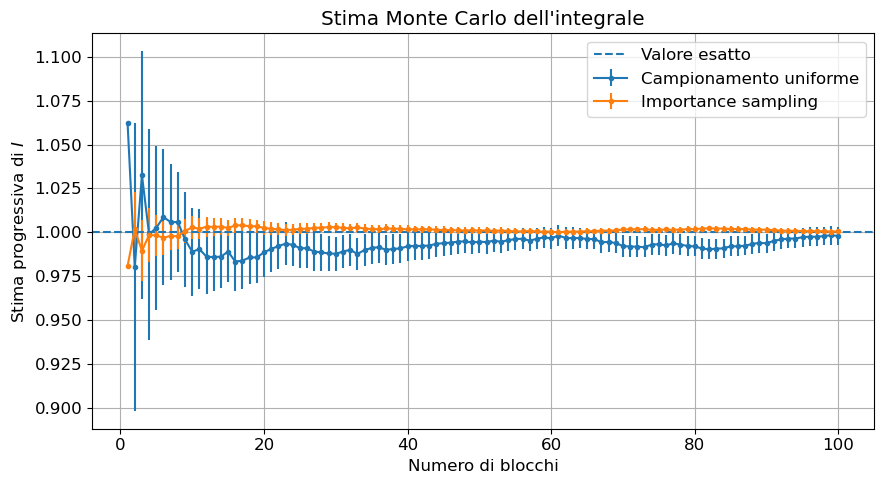

In [3]:
plt.figure(figsize=(9, 5))

plt.errorbar(
    blocks_uniform, integral_uniform, yerr=error_uniform,
    marker=".", linestyle="-", label="Campionamento uniforme"
)
plt.errorbar(
    blocks_importance, integral_importance, yerr=error_importance,
    marker=".", linestyle="-", label="Importance sampling"
)
plt.axhline(exact_integral, linestyle="--", label="Valore esatto")

plt.xlabel("Numero di blocchi")
plt.ylabel(r"Stima progressiva di $I$")
plt.title("Stima Monte Carlo dell'integrale")
plt.legend()
plt.tight_layout()
plt.show()

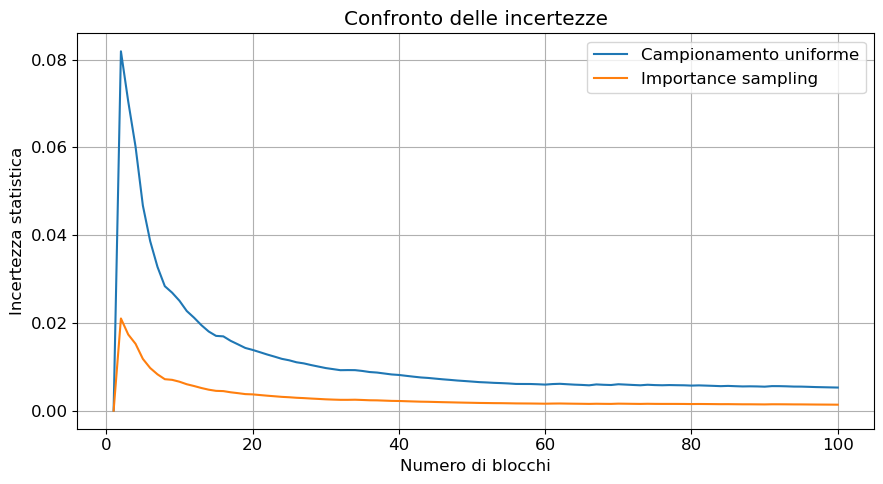

In [4]:
plt.figure(figsize=(9, 5))

plt.plot(blocks_uniform, error_uniform, label="Campionamento uniforme")
plt.plot(blocks_importance, error_importance, label="Importance sampling")

plt.xlabel("Numero di blocchi")
plt.ylabel("Incertezza statistica")
plt.title("Confronto delle incertezze")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
print("Risultati finali esercizio 02.1")
print(f"Campionamento uniforme: I = {integral_uniform[-1]:.6f} ± {error_uniform[-1]:.6f}")
print(f"Importance sampling:    I = {integral_importance[-1]:.6f} ± {error_importance[-1]:.6f}")
print(f"Valore esatto:          I = {exact_integral:.6f}")

Risultati finali esercizio 02.1
Campionamento uniforme: I = 0.997939 ± 0.005284
Importance sampling:    I = 1.000540 ± 0.001382
Valore esatto:          I = 1.000000


### Commento

Entrambi i metodi devono convergere al valore teorico $I=1$ entro le incertezze statistiche. La differenza principale non è il valore medio finale, ma l'ampiezza dell'errore.

L'importance sampling fornisce un'incertezza più piccola perché la densità scelta, $p(x)=2(1-x)$, ha un andamento simile a quello dell'integranda. Di conseguenza il rapporto $f(x)/p(x)$, cioè la quantità effettivamente mediata nella simulazione, risulta più piatto rispetto a $f(x)$ campionata uniformemente. La varianza della stima si riduce e, a parità di numero di lanci, l'errore statistico è minore.

Questo miglioramento non è automatico: dipende dalla scelta di una densità normalizzata, campionabile in modo semplice e abbastanza simile alla forma dell'integranda.


## Esercizio 02.2 — Random walk tridimensionale

Si simulano random walk tridimensionali sempre a partire dall'origine. I casi richiesti sono due:

1. random walk su reticolo cubico con passo $a=1$ lungo una delle sei direzioni $\pm x$, $\pm y$, $\pm z$;
2. random walk nel continuo con passo di lunghezza $a=1$ e direzione casuale uniforme sull'angolo solido.

La quantità da stimare in funzione del numero di passi $N$ è

$$
\sqrt{\langle |\vec r_N|^2\rangle_{RW}}.
$$


### Metodo

Per ogni cammino si considera la posizione

$$
\vec r_N=(x_N,y_N,z_N)
$$

al passo $N$, da cui

$$
|\vec r_N|^2=x_N^2+y_N^2+z_N^2.
$$

I cammini sono divisi in blocchi. Per ogni blocco e per ogni valore di $N$ viene calcolata direttamente la grandezza

$$
R_{\text{blocco}}(N)=\sqrt{\langle |\vec r_N|^2\rangle_{\text{blocco}}}.
$$

Nel C++ questo corrisponde a due operazioni consecutive: prima si calcola la media di $r^2$ nel blocco, `block_avg_squared_distance = block_squared_distance_sum[step]/n_walks_per_block`, poi si prende la radice, `block_distance = sqrt(block_avg_squared_distance)`. L'errore statistico viene quindi stimato applicando il data blocking direttamente ai valori $R_{\text{blocco}}(N)$, senza propagare l'errore attraverso la radice quadrata.

Per il random walk continuo bisogna campionare correttamente la direzione del passo. Una direzione uniforme sulla sfera non si ottiene estraendo $\theta$ uniformemente in $[0,\pi]$. Bisogna invece estrarre $\phi$ uniformemente in $[0,2\pi]$ e $\cos\theta$ uniformemente in $[-1,1]$. Nel codice questa scelta è rappresentata dalle variabili `phi`, `cos_theta` e `sin_theta = sqrt(1.0 - cos_theta*cos_theta)`.


In [6]:
# File prodotti dal codice C++ dell'esercizio 02.2
lattice_data = load_three_columns("results/rw_lattice.txt")
continuum_data = load_three_columns("results/rw_continuum.txt")

steps_lattice = lattice_data[:, 0]
r_lattice = lattice_data[:, 1]
err_lattice = lattice_data[:, 2]

steps_continuum = continuum_data[:, 0]
r_continuum = continuum_data[:, 1]
err_continuum = continuum_data[:, 2]


In [7]:
def fit_sqrt_law(steps, values, errors):
    # Fit pesato a un parametro: values = k * sqrt(steps).
    steps = np.asarray(steps)
    values = np.asarray(values)
    errors = np.asarray(errors)

    mask = (steps > 0) & (errors > 0) & np.isfinite(values) & np.isfinite(errors)
    x = np.sqrt(steps[mask])
    y = values[mask]
    sigma = errors[mask]

    weights = 1.0 / sigma**2

    # Soluzione analitica del fit lineare a un parametro y = kx.
    k = np.sum(weights * x * y) / np.sum(weights * x**2)
    k_err = np.sqrt(1.0 / np.sum(weights * x**2))


    return k, k_err


k_lattice, k_lattice_err = fit_sqrt_law(steps_lattice, r_lattice, err_lattice)
k_continuum, k_continuum_err = fit_sqrt_law(steps_continuum, r_continuum, err_continuum)

max_step = int(max(steps_lattice.max(), steps_continuum.max()))
x_fit = np.linspace(0, max_step, 400)


### Random walk su reticolo cubico

Nel caso discreto, a ogni passo viene scelta con uguale probabilità una delle sei direzioni $\pm x$, $\pm y$, $\pm z$. La figura mostra separatamente il confronto con la legge diffusiva attesa, così le barre d'errore e il fit risultano più leggibili rispetto a un grafico sovrapposto.


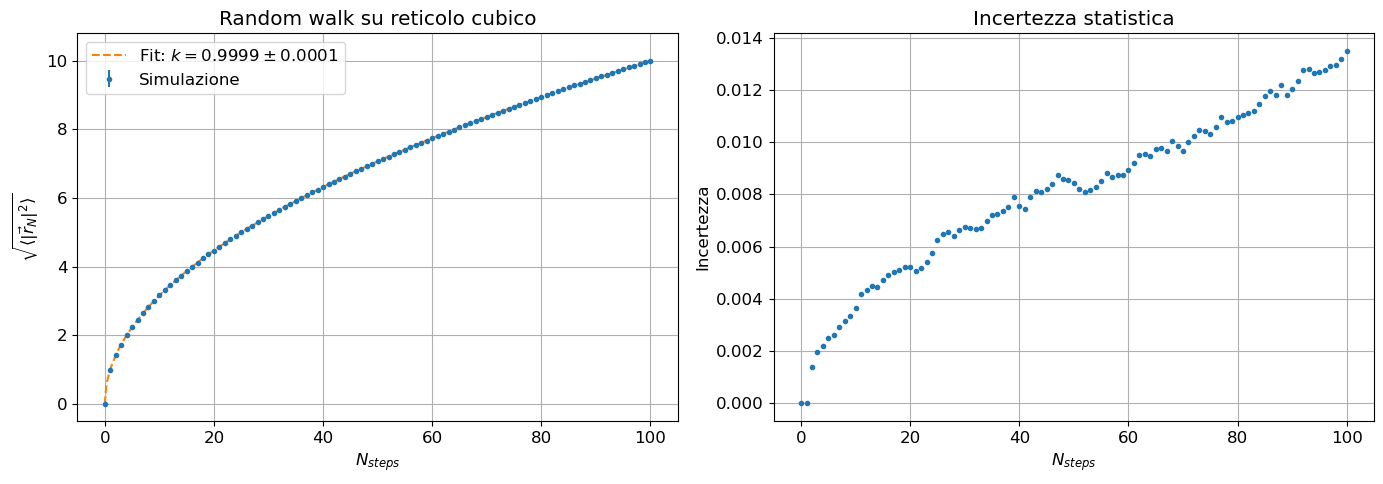

In [8]:
y_fit_lattice = k_lattice * np.sqrt(x_fit)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].errorbar(
    steps_lattice, r_lattice, yerr=err_lattice,
    fmt="o", markersize=3, label="Simulazione"
)
axes[0].plot(
    x_fit, y_fit_lattice, linestyle="--",
    label=rf"Fit: $k={k_lattice:.4f}\pm{k_lattice_err:.4f}$"
)
axes[0].set_title("Random walk su reticolo cubico")
axes[0].set_xlabel("$N_{steps}$")
axes[0].set_ylabel(r"$\sqrt{\langle |\vec r_N|^2\rangle}$")
axes[0].legend()
axes[0].set_ylim(bottom=-0.5, top=10.8)

axes[1].plot(steps_lattice, err_lattice, marker="o", linestyle="", markersize=3)
axes[1].set_title("Incertezza statistica")
axes[1].set_xlabel("$N_{steps}$")
axes[1].set_ylabel("Incertezza")

plt.tight_layout()
plt.show()


### Random walk nel continuo

Nel caso continuo il passo ha sempre lunghezza $a=1$, ma la direzione è estratta uniformemente sull'angolo solido. Anche qui il comportamento atteso è diffusivo, cioè proporzionale a $\sqrt{N}$.


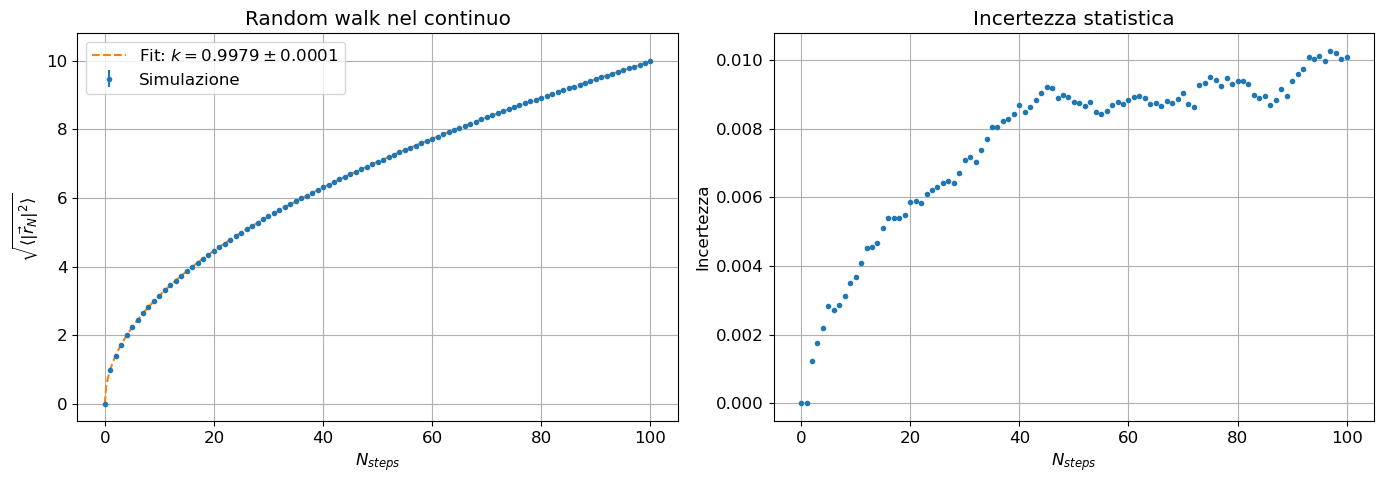

In [9]:
y_fit_continuum = k_continuum * np.sqrt(x_fit)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].errorbar(
    steps_continuum, r_continuum, yerr=err_continuum,
    fmt="o", markersize=3, label="Simulazione"
)
axes[0].plot(
    x_fit, y_fit_continuum, linestyle="--",
    label=rf"Fit: $k={k_continuum:.4f}\pm{k_continuum_err:.4f}$"
)
axes[0].set_title("Random walk nel continuo")
axes[0].set_xlabel("$N_{steps}$")
axes[0].set_ylabel(r"$\sqrt{\langle |\vec r_N|^2\rangle}$")
axes[0].legend()
axes[0].set_ylim(bottom=-0.5, top=10.8)

axes[1].plot(steps_continuum, err_continuum, marker="o", linestyle="", markersize=3)
axes[1].set_title("Incertezza statistica")
axes[1].set_xlabel("$N_{steps}$")
axes[1].set_ylabel("Incertezza")

plt.tight_layout()
plt.show()

In [10]:
print("Risultati finali esercizio 02.2")
print(f"Reticolo cubico: k = {k_lattice:.6f} ± {k_lattice_err:.6f}")
print(f"Continuo:        k = {k_continuum:.6f} ± {k_continuum_err:.6f}")
print("Valore teorico atteso: k = 1")

Risultati finali esercizio 02.2
Reticolo cubico: k = 0.999855 ± 0.000121
Continuo:        k = 0.997858 ± 0.000115
Valore teorico atteso: k = 1


### Commento finale

I risultati devono essere compatibili con

$$
\sqrt{\langle |\vec r_N|^2\rangle}\propto \sqrt{N}.
$$

La verifica quantitativa passa dal fit $f(N)=k\sqrt{N}$: il parametro $k$ deve risultare vicino al valore teorico $k=1$.

Il risultato atteso è lo stesso per il random walk su reticolo e per quello nel continuo. In entrambi i casi i passi sono indipendenti, isotropi in media e di lunghezza fissata $a=1$; cambia solo il modo in cui viene scelta la direzione del singolo passo. I grafici separati rendono più leggibile questo confronto senza sovrapporre troppe informazioni nella stessa figura.
